In [62]:
import pickle   # importing pickle for saving and loading machine learning models
import pandas as pd  # importing pandas for analyzing, cleaning, exploring, and manipulating data
from sklearn.model_selection import train_test_split  # importing train_test_split for spliting the data
from preprocess import *  # importing * for import all functions at once
from imblearn.over_sampling import SMOTE  # importing SMOTE for Balancing the Data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
import numpy as np

In [6]:
#!pip install preprocess

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
df=pd.read_csv("BreastCancerDataset.csv")
df.head(8)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN


In [12]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [13]:
df.isnull().sum() #Null values not present in dataset.

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [16]:
import sys
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
#path = "/content/drive/MyDrive/Certified Data Science/04-Machine Learning Expert/SVM/preprocessor.pkl"
try:
    with open('/content/BreastCancerPreprocessor.pkl', "rb") as f:
        preprocessor = pickle.load(f)
    print("Preprocessor loaded successfully!")
except Exception as e:
    print(f"Failed to load preprocessor: {e}")

Preprocessor loaded successfully!


In [17]:
preprocessor

ColumnTransformer(transformers=[('Standard_scaler', StandardScaler(),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
                                  'perimeter_worst', 'area_worst',
                                  'smoothness_worst', 'compactness_worst',
                                  'concavity_worst', 'concave points_worst',
                                  'symmetry_worst',
                                  'fractal_dimension_worst'])])

In [18]:
df.isnull().sum() #no Null Values in datset found.

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [49]:
X=df.drop('diagnosis',axis=1)
Y=df['diagnosis']

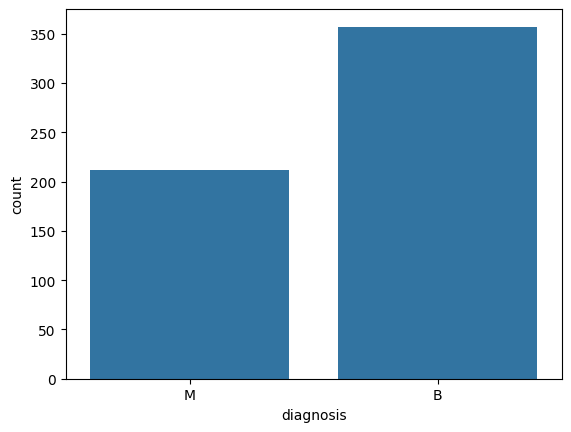

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y)
plt.show()

In [42]:
le = LabelEncoder()
Y = le.fit_transform(df['diagnosis'])
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [43]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

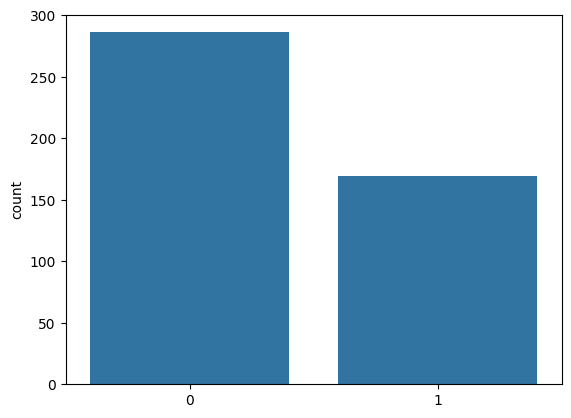

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y_train)
plt.show()

In [51]:
len(Y_train)

455

In [47]:
import sys
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

Proprocessed_X_train = preprocessor.fit_transform(X_train)
Preprocessed_X_test=preprocessor.transform(X_test)
print(Proprocessed_X_train)

[[-1.44075296 -0.43531947 -1.36208497 ...  0.9320124   2.09724217
   1.88645014]
 [ 1.97409619  1.73302577  2.09167167 ...  2.6989469   1.89116053
   2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 ... -0.97023893  0.59760192
   0.0578942 ]
 ...
 [ 0.04880192 -0.55500086 -0.06512547 ... -1.23903365 -0.70863864
  -1.27145475]
 [-0.03896885  0.10207345 -0.03137406 ...  1.05001236  0.43432185
   1.21336207]
 [-0.54860557  0.31327591 -0.60350155 ... -0.61102866 -0.3345212
  -0.84628745]]


In [53]:
smote=SMOTE()
X_train_smote,Y_train_smote=smote.fit_resample(Proprocessed_X_train,Y_train)

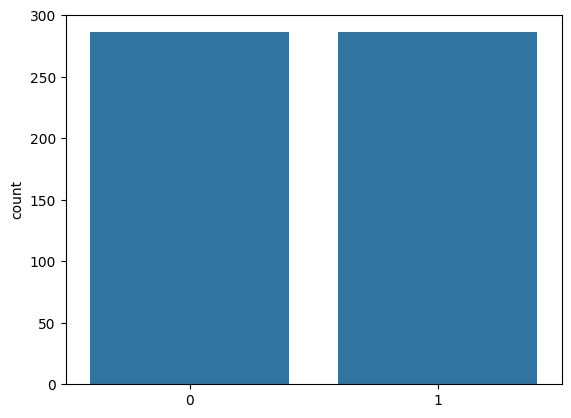

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y_train_smote)
plt.show()

In [65]:
error_rate=[]
for i in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_smote,Y_train_smote)
    pred_i=knn.predict(Preprocessed_X_test)
    error=np.mean(pred_i!=Y_test)
    error_rate.append(error)
    print("Error Rate for",i,"nearest neighbors is",error)

Error Rate for 1 nearest neighbors is 0.05263157894736842
Error Rate for 2 nearest neighbors is 0.05263157894736842
Error Rate for 3 nearest neighbors is 0.05263157894736842
Error Rate for 4 nearest neighbors is 0.05263157894736842
Error Rate for 5 nearest neighbors is 0.043859649122807015
Error Rate for 6 nearest neighbors is 0.05263157894736842
Error Rate for 7 nearest neighbors is 0.043859649122807015
Error Rate for 8 nearest neighbors is 0.043859649122807015
Error Rate for 9 nearest neighbors is 0.043859649122807015
Error Rate for 10 nearest neighbors is 0.03508771929824561
Error Rate for 11 nearest neighbors is 0.043859649122807015
Error Rate for 12 nearest neighbors is 0.03508771929824561
Error Rate for 13 nearest neighbors is 0.03508771929824561
Error Rate for 14 nearest neighbors is 0.043859649122807015
Error Rate for 15 nearest neighbors is 0.03508771929824561
Error Rate for 16 nearest neighbors is 0.043859649122807015
Error Rate for 17 nearest neighbors is 0.04385964912280701

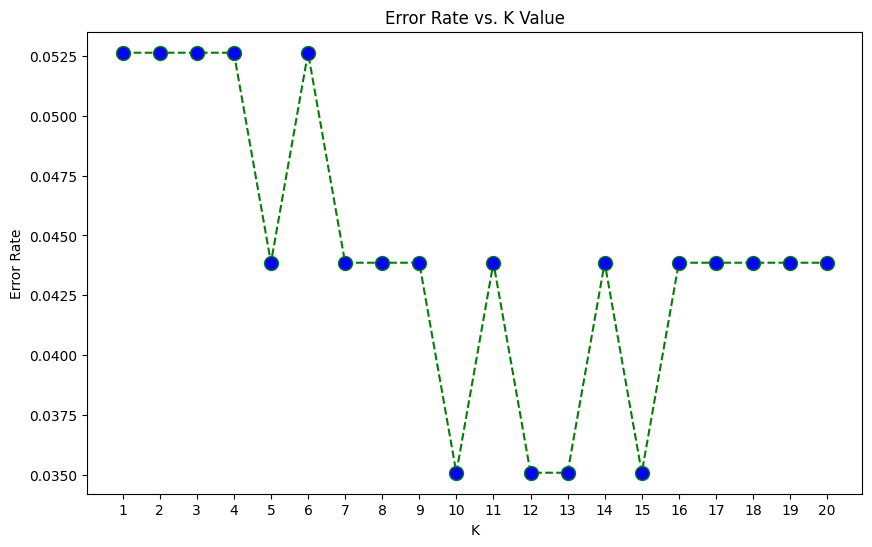

In [83]:
plt.figure(figsize=(10,6))
x=range(1,21)
plt.plot(x,error_rate,color='green', linestyle='dashed',
         marker='o',markerfacecolor='blue', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(x)
plt.show()

In [85]:
knn=KNeighborsClassifier(n_neighbors=10)  #K could be 10,12,13,15
knn.fit(X_train_smote,Y_train_smote)
y_pred=knn.predict(Preprocessed_X_test)

In [89]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score,f1_score
acc=accuracy_score(y_pred,Y_test)
print("Accuracy Score is",acc)

Accuracy Score is 0.9649122807017544


In [90]:
recall_score=recall_score(y_pred,Y_test)
recall_score

0.9534883720930233

In [92]:
f1_score=f1_score(y_pred,Y_test)
f1_score

0.9534883720930233

In [93]:
print(classification_report(y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [94]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
root_mean_squared_error_value=[]
mean_squared_error_value=[]
for K in range(1,11):
  model=KNeighborsRegressor(n_neighbors=K)
  model.fit(X_train_smote,Y_train_smote)
  pred=model.predict(Preprocessed_X_test)
  mean_square_error=mean_squared_error(Y_test,pred) #calculated mse
  root_mean_squared_error=np.sqrt(mean_square_error) #calculate rmse
  root_mean_squared_error_value.append(root_mean_squared_error) #store rmse values

  mean_squared_error_value.append(mean_square_error) #stores mse
  mae = mean_absolute_error(Y_test,pred)
  print("Mean Absolute Error for",K,"nearest neighbors is",mae)
  print('Mean Squared Error for' , K ,'nearest neighbors is:',mean_square_error)
  print('Root Mean Squared Error for' , K ,'nearest neighbors is:',root_mean_squared_error)

Mean Absolute Error for 1 nearest neighbors is 0.05263157894736842
Mean Squared Error for 1 nearest neighbors is: 0.05263157894736842
Root Mean Squared Error for 1 nearest neighbors is: 0.22941573387056177
Mean Absolute Error for 2 nearest neighbors is 0.05263157894736842
Mean Squared Error for 2 nearest neighbors is: 0.043859649122807015
Root Mean Squared Error for 2 nearest neighbors is: 0.20942695414584775
Mean Absolute Error for 3 nearest neighbors is 0.06140350877192982
Mean Squared Error for 3 nearest neighbors is: 0.043859649122807015
Root Mean Squared Error for 3 nearest neighbors is: 0.20942695414584775
Mean Absolute Error for 4 nearest neighbors is 0.06359649122807018
Mean Squared Error for 4 nearest neighbors is: 0.04550438596491228
Root Mean Squared Error for 4 nearest neighbors is: 0.2133175706895995
Mean Absolute Error for 5 nearest neighbors is 0.06315789473684212
Mean Squared Error for 5 nearest neighbors is: 0.03929824561403509
Root Mean Squared Error for 5 nearest nei